# NB1 : Generating Keys and Data Cleaning

**Purpose**: To perform the initial data cleaning on the raw data set pulled using [Publish or Perish]( https://harzing.com/resources/publish-or-perish) web scraping software.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part 1: Creating Keys To Link Databases

###  Importing raw data files

Data frame descriptions:

`query_df`: This data frame contains the meta data for each of the sampled Google Scholar profiles.

`papers_df`: This data frame containing *all* the citation entries for each the first 1000 papers pulled from the Google Scholar profiles. The features in this column are:

   - `Cites`: The number of citations the paper has received.
   - `Authors`: The names of the authors (Not all included)
   - `Title`: The title of the entry 
   - `Source`: The title of the journal where the entry is published.
   - `Year`: The Year of entry's publication.
   - `CitesURL`: URL to cite the paper.

In [2]:
query_df = pd.read_csv(r"G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Export\author_PoPMetrics_V2.2.csv")
papers_df = pd.read_csv(r"G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Export\results_PoPCites_V2.2.csv",low_memory = True)

In [3]:
query_df.head(3)

,id,Query,Source,Papers,Citations,Years,Cites_Year,Cites_Paper,Cites_Author,Papers_Author,...,g_coverage,star_count,year_first,year_last,ECC,acc1,acc2,acc5,acc20,hA
0,0,Edward Sargent - University of Toronto,Google Scholar Profile,1000,119190,27,4414.44,119.19,22989.19,225.13,...,88.1,383,1996,2023,119190,751,665,517,247,69
1,1,Norbert Koch - Institut für Physik &IRIS Adler...,Google Scholar Profile,560,26197,26,1007.58,46.78,5580.69,106.68,...,83.4,76,1997,2023,26197,337,285,166,30,24
2,2,"Dieter Neher - University of Potsdam, Institut...",Google Scholar Profile,559,36923,87,424.40,66.05,7764.41,115.04,...,86.3,122,1936,2023,36923,329,274,183,65,31


In [4]:
papers_df.head(3)

,Cites,Authors,Title,Year,Source,Publisher,ArticleURL,CitesURL,GSRank,QueryDate,...,StartPage,EndPage,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,Age,Abstract,FullTextURL,RelatedURL
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015.0,Science,NaN,NaN,https://scholar.google.com/scholar?oi=bibs&hl=...,1,2023-03-02 08:59:01,...,519.0,522.0,4186,523.25,523,8,8.0,NaN,NaN,NaN
1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018.0,Nature,NaN,NaN,https://scholar.google.com/scholar?oi=bibs&hl=...,2,2023-03-02 08:59:01,...,245.0,248.0,2319,463.80,258,9,5.0,NaN,NaN,NaN
2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005.0,Nature materials,NaN,NaN,https://scholar.google.com/scholar?oi=bibs&hl=...,3,2023-03-02 08:59:01,...,138.0,142.0,2163,120.17,309,7,18.0,NaN,NaN,NaN


### Creating Foreign Keys 

**Goal**: Create foreign keys to link entries in `papers_id` with their Google Scholar profile in `query_df`

**Method**: We will create a new column in `papers_id` called `query_id` which will hold a foreign key to link the entires in the `papers_df` with their respective Google scholar profiles in `query_df`. This will be used to join the `papers_df` and `query_df` with `query_id` and `id` respectively. Since the web scrapper sorted the entries in `papers_df` in descending order by `Citations`, we will identify which entry in `papers_df` correspond to which Google scholar profiles in `query_df` by finding where the values in `Citations` reset to a values than is greater than the previous entry in `Citations`.

*Example*: Below is an example entries of `papers_df` demonstrating that at index 5, the `query_id` value switches to a different key since the value in the `Citations` column (10) reset to a values than is greater than the previous entry in `Citations` at index 4 (0).



| Index | Citations | query_id |
--- | --- | ---|
|0|5|0|
|1|3|0|
|2|2|0|
|3|0|0|
|4|0|0|
|5|10|1|
|6|7|1|

In [5]:
cites = papers_df.loc[:, 'Cites'].values

# Get the number of rows in the papers_df
rows, cols = papers_df.shape

# Get indexs for start and stop
start_list = [0]
end_list = []

for i in range(rows):
    j = i + 1
    if j >= rows:
        break
    else:
        if cites[j]-cites[i] > 0:
            end_list.append(i)
            start_list.append(j)

end_list.append(rows)

au_rows, au_cols = query_df.shape

# Assign query_ids
query_id = np.zeros(rows)
for i in range(au_rows):
    start, stop = start_list[i], end_list[i]+1
    query_id[start:stop] = i

# Save query series to df
quer_ser = pd.Series(query_id)
papers_df['query_id'] = quer_ser

We see that the `papers_df` has a new column `query_id`

In [6]:
papers_df['query_id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 33531 entries, 0 to 33530
Series name: query_id
Non-Null Count  Dtype  
--------------  -----  
33531 non-null  float64
dtypes: float64(1)
memory usage: 262.1 KB


In [7]:
papers_df['query_id'].value_counts()

0.0      1000
1.0       560
2.0       559
3.0       503
4.0       414
         ... 
611.0       2
612.0       2
613.0       2
614.0       2
615.0       2
Name: query_id, Length: 616, dtype: int64

We can check if all the entires in the `query_df` are accounted for in the `query_id` column by checking if the unique values in the `query_id` column equals the number of entries in the `query_df`.

In [8]:
papers_df['query_id'].value_counts().count() == query_df.shape[0]

True

The number of entries match, suggesting that generating the value for the `query_id` column was successful! Let's save the resulting `papers_df` into `pickle`.

In [9]:
papers_df.to_pickle(r"2023-03-20_NB1_papers_df_part1.pkl")

### Conclusion

We now have a foreign key to join the entires in `papers_df` to `query_df`. This will be helpful when needing to access information only available in the from the `query_df` for each entry.

## Part 2: Addressing Null Values in `papers_df`

**Goal**: We want to remove null values from the `papers_df` while still preserving as much information as possible for ranking *publication* entries. Therefore, we will prioritize *not* deleting columns that store information about the citation that could determine its publication rank such as...
- `Source`
- `Type`
-  `Authors`
- `Citations`
- `GSRank`
- `ECC`

...and instead investigate if it is possible to either mass source the null information (by pulling the information from another column, for example) or determine if the entry is not relevant to creating a data base of publications (for example, if the entry is of a non-publication citation like a poster, workshop, lecture, data base entry, etc.).

Let's access the fraction of null values in `papers_df`for each column

In [10]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

Abstract          1.000000
Age               0.037547
ArticleURL        1.000000
AuthorCount       0.000000
Authors           0.000596
CitationURL       0.000000
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
CitesURL          0.000000
DOI               1.000000
ECC               0.000000
EndPage           0.259968
FullTextURL       1.000000
GSRank            0.000000
ISSN              1.000000
Issue             0.429692
Publisher         0.993499
QueryDate         0.000000
RelatedURL        1.000000
Source            0.062569
StartPage         0.253377
Title             0.000000
Type              0.116042
Volume            0.227223
Year              0.037547
query_id          0.000000
dtype: float64

Let's drop the columns were over 99% of the entires are null values.

In [11]:
papers_df = papers_df.drop(['Abstract', 'ArticleURL', 'DOI', 'FullTextURL', 'ISSN', 'RelatedURL', 'Publisher'], axis = 1)

In [12]:
papers_df.head(3)

,Cites,Authors,Title,Year,Source,CitesURL,GSRank,QueryDate,Type,CitationURL,Volume,Issue,StartPage,EndPage,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,Age,query_id
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015.0,Science,https://scholar.google.com/scholar?oi=bibs&hl=...,1,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,347.0,6221.0,519.0,522.0,4186,523.25,523,8,8.0,0.0
1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018.0,Nature,https://scholar.google.com/scholar?oi=bibs&hl=...,2,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,562.0,7726.0,245.0,248.0,2319,463.80,258,9,5.0,0.0
2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005.0,Nature materials,https://scholar.google.com/scholar?oi=bibs&hl=...,3,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,4.0,2.0,138.0,142.0,2163,120.17,309,7,18.0,0.0


Let's look at the sources of remaining null values.

In [13]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

Age               0.037547
AuthorCount       0.000000
Authors           0.000596
CitationURL       0.000000
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
CitesURL          0.000000
ECC               0.000000
EndPage           0.259968
GSRank            0.000000
Issue             0.429692
QueryDate         0.000000
Source            0.062569
StartPage         0.253377
Title             0.000000
Type              0.116042
Volume            0.227223
Year              0.037547
query_id          0.000000
dtype: float64

We can remove columns such as `Volume`, `StartPage`, `EndPage` and `Issue` since it just includes additional citation information that can be used to find the journal entry, and not information that could rank of the citation entry. The citation entries can be found using the authors, article title and source so these columns are not needed. We can also drop `Age` since we can determine the age of the citation from the year it was published.

In [14]:
papers_df = papers_df.drop(['Age', 'Volume', 'StartPage', 'EndPage', 'Issue'], axis = 1)

We can also remove the columns `CitesURL`, `QueryDate` and `CitationURL` since they don't contain useful data for our model.

In [15]:
papers_df = papers_df.drop(['CitesURL', 'QueryDate', 'CitationURL'], axis = 1)

Let's look at the remaining null values.

In [16]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

AuthorCount       0.000000
Authors           0.000596
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
ECC               0.000000
GSRank            0.000000
Source            0.062569
Title             0.000000
Type              0.116042
Year              0.037547
query_id          0.000000
dtype: float64

Let's investigate the where the null values for the `Authors` column are.

In [17]:
papers_df[papers_df['Authors'].isna()].sample(5)

,Cites,Authors,Title,Year,Source,GSRank,Type,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
29303,18,NaN,Enhanced energy confinement after series of pe...,2020.0,Plasma Physics and Controlled Fusion,6,Journal article,18,6.0,0,0,309.0
32341,0,NaN,Purcell Enhancement of the Spontaneous Emissio...,2019.0,Poster,13,Conference paper,0,0.0,0,0,469.0
29308,10,NaN,First neutral beam experiments on Wendelstein 7-X,2021.0,Nuclear Fusion,11,Journal article,10,5.0,0,0,309.0
9511,0,NaN,Exploiting Ternary Blends to Accurately Contro...,NaN,NaN,268,NaN,0,0.0,0,0,24.0
17690,0,NaN,Development of Geopolymers for Catalyst Suppor...,NaN,"MATERIALS RESEARCH,",89,NaN,0,0.0,0,0,78.0


Since these entries only account for about 0.6% of the entires, there is reason to just remove the rows. However, there might be other entries in the data set with the same titles, such that deleting these entries as a duplicate will ensure the entry is accounted for while still removing null values. Let's see if there are any entries with the same values in the `Title` column.

First, let's find duplicate entries in the data frame (where all entry values are duplicated).

In [18]:
num = papers_df.duplicated().sum()
per = num/papers_df.shape[0]
print('There are {} duplicated rows, that is {:0.2%} of the entires in papers_df!'.format(num, per))

There are 0 duplicated rows, that is 0.00% of the entires in papers_df!


There are no entires that are entirely duplicated, let's move to investigate entires where their values for `Title` are duplicated.

In [19]:
num = papers_df.duplicated('Title').sum()
per = num/papers_df.shape[0]
print('There are {} duplicated rows, that is {:0.2%} of the entires in papers_df!'.format(num, per))

There are 7805 duplicated rows, that is 23.28% of the entires in papers_df!


Despite them accounting for 23.28% of the entires in `papers_df`, let's remove the entires with duplicate titles. These duplicates most likely arose from 'lower-ranked' Google Scholar profiles including the same citations as 'higher-ranked' Google Scholar profiles since the researcher of the 'lower-ranked' Google Scholar profiles was an author on the paper along with the researcher of the 'higher-ranked' Google Scholar profile. Since information such as authorship order, and overall ranking of the citation entry will be the same, regardless of who's Google Scholar profile the citation is pulled from, we'll remove the duplicate citations corresponding the to 'lower-ranked' Google Scholar profiles. 

*Note*: This decision has the caveat of researchers from lower-ranked' Google Scholar profiles not being associated with the paper if they are not one of the first 5-7 authors on the publication. However, since authors (aside for corresponding authorships) who are listed beyond the 3rd author often are considered to have a negligible impact to the quality of the publication, we chose to move forward with deleting the the duplicate article entries despite the caveat.

In [20]:
papers_df = papers_df.drop_duplicates(subset = 'Title', keep = 'first', ignore_index = False)

In [21]:
num = papers_df.duplicated('Title').sum()
per = num/papers_df.shape[0]
print('There are {} duplicated rows, that is {:0.2%} of the entires in papers_df!'.format(num, per))

There are 0 duplicated rows, that is 0.00% of the entires in papers_df!


We've successfully removed the entires with duplicated values for `Title`. Let's look again at the null values.

In [22]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

AuthorCount       0.000000
Authors           0.000350
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
ECC               0.000000
GSRank            0.000000
Source            0.061416
Title             0.000000
Type              0.115875
Year              0.037433
query_id          0.000000
dtype: float64

The `Author` column still has a few null values, though the number of entires drop from representing 0.596% of the data to 0.350% of the data. Let's go a head and drop those entires.

In [23]:
papers_df = papers_df.dropna(subset = 'Authors')

In [24]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Type              0.115760
Source            0.061399
Year              0.037368
Cites             0.000000
Authors           0.000000
Title             0.000000
GSRank            0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

Let's investigate the entires that have a null value in their `Type` column.

In [25]:
papers_df[papers_df['Type'].isna()].sample(5)

,Cites,Authors,Title,Year,Source,GSRank,Type,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
25434,0,"YV Korshak, RA Dvorikova, LN Nikitin, VA Shand...",Magnetic nanoparticles in polymers,2014.0,Engineering of Polymers and Chemical Complexit...,38,NaN,0,0.0,0,6,198.0
29017,0,B Turedi,New Strategies for High Efficiency Perovskite ...,2021.0,NaN,26,NaN,0,0.0,0,1,298.0
12034,0,"N Mathews, S Mhaisalkar, A Bruno",Sustainable Energy &Fuels,2022.0,NaN,148,NaN,0,0.0,0,3,35.0
7473,0,"H Zhong, K Gu",A General Methodology to Measure the Light-to-...,2022.0,NaN,225,NaN,0,0.0,0,2,17.0
24824,0,"C Tiflidis, E Topoglidis",Electrochemical Biosensors Based on Protein Im...,NaN,NaN,44,NaN,0,0.0,0,2,185.0


Some of the entires with null values of `Type` also have null values for `Source`. Let's find out how many.

In [26]:
num = papers_df[papers_df['Type'].isna() & papers_df['Source'].isna()].shape[0]
per = num/papers_df[papers_df['Type'].isna()].shape[0]
print('{:0.2%} of the entries with null values for Type also have a null value for Source'.format(per))
print(f'Thats {num} entries')

49.92% of the entries with null values for Type also have a null value for Source
Thats 1486 entries


Let's address the null values for `Type` based on if they have a null value for `Source`. Let's look up an entry with a null value for `Type` and `Source` to try to see what the source is.

In [27]:
print('Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)')

i = 0
while i <= 5:
    val = papers_df[papers_df['Type'].isna() & papers_df['Source'].isna()].sample(10)['Title'].values[i]
    print(val)
    i += 1

Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)
Thermal stability of Pd based hexaaluminate catalysts for CH4 combustion. Comparison with Pd/Al2O3 catalyst.
Estudo da teoria do funcional da densidade aplicado às simulações de propriedades eletrônicas e estruturais de semicondutores
ESTUDO DE DISPOSITIVOS SPINTRÔNICOS
Structural Condition of Detonation Nanodiamonds under High Pressure High Temperature Sintering
Session 4: Hydrogen generation by redox thermochemical cycles H {sub 2} O/Rh-SiO {sub 2} and H {sub 2} O/Rh-CeO {sub 2}
MRS Advances


Results of Investigation:
1. `Development of binder system for manufacturing metallic and ceramic parts by Powder Injection Molding technology`
    1. This is a [archive entry](https://e-archivo.uc3m.es/handle/10016/3105) for a journal which is why it does not have a source.
2. `A chemical sensor based on a photonic-crystal L3 nanocavity defined into a silicon-nitride membrane`
    1. This is a citation for an [un-published manuscript](https://www.researchgate.net/profile/David-Lidzey/publication/265136954_A_chemical_sensor_based_on_a_photonic-crystal_L3_nanocavity_defined_in_a_silicon-nitride_membrane/links/583c103e08ae502a85e37e74/A-chemical-sensor-based-on-a-photonic-crystal-L3-nanocavity-defined-in-a-silicon-nitride-membrane.pdf) 
3. `Asimplifiedtight-bindingapproachtotheinvestigationofelectronicstructures intwistedbilayergrapheneandtransitionmetaldichalcogenides`
    1. This is a citation for a [poster](https://www.researchgate.net/profile/Lucas-Taveira-Caleiro/publication/361639433_A_simplified_tight-binding_approach_to_the_investigation_of_electronic_structures_in_twisted_bilayer_graphene_and_transition_metal_dichalcogenides/links/62bd89f288d96f1e6b2f9404/A-simplified-tight-binding-approach-to-the-investigation-of-electronic-structures-in-twisted-bilayer-graphene-and-transition-metal-dichalcogenides.pdf)
4. `The intercalated graphite obtained in the system C-HNO {sub 3}-R-CH {sub 3} COOH, where R= H {sub 3} PO {sub 4}: synthesis, properties and application; Interkalirovanniy grafit …`
    1. This is a [conference abstract](https://www.osti.gov/etdeweb/biblio/22466046) 
5. `EFFECTIVE MEDIA THEORY ADAPTED FOR SCANING NEAR-FIELD OPTICAL MICROSCOPY SIMULATIONS`
    1. This is a [poster abstract](https://www.phantomsnet.net/FyT08/files/Abstracts/Poster/FYT2008_CanetFerrer.pdf) 

From the investigation, it looks like the our sample set were entires without a `Source` or `Type` entry are not a journal entry, rather misc. entries. Since we only want to focus on entires from sources that have their own ranks assigned to them, such as journals, conference papers or books, let's remove all the entires that aren't categorized by those types.

First, let's look at the distribution of entires by their type.

Text(0.5, 1.0, 'Distribution of Entry Types')

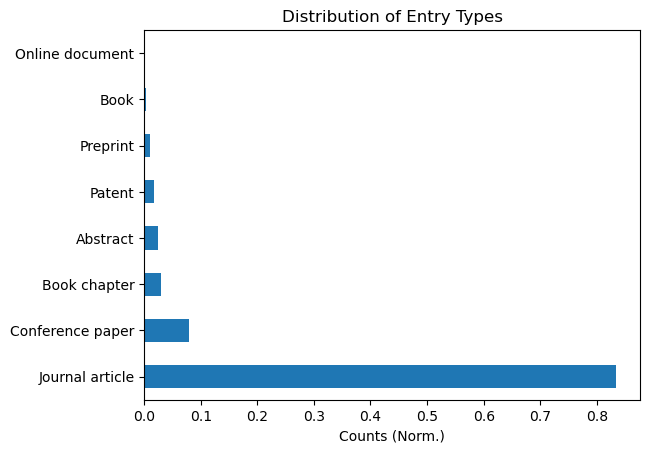

In [28]:
papers_df['Type'].value_counts(normalize = True).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Entry Types')

It looks like over 80% of the entries are with non-null types are categorized as `Journal Article` with `Conference paper` taking up about 10% and `Book` has less than 5% of the entries. Therefore, we should be able to capture over 90% of the entires with non-null types by only considering entries with `Journal Article`, `Conference paper` or `Book` as its value for `Type`.

In [29]:
new_df = papers_df[(papers_df['Type'] == 'Journal article') | (papers_df['Type'] == 'Conference paper') | (papers_df['Type'] == 'Book')]
per = new_df.shape[0]/papers_df.shape[0]
print('Only including entires of the designated types will encompase {:0.2%} of the original entries'.format(per))
print(f'Thats {new_df.shape[0]} rows')

Only including entires of the designated types will encompase 81.08% of the original entries
Thats 20852 rows


Since we will still have close to 20,000 entires after only including entires `Journal Article`, `Conference paper` or `Book`, let's go ahead an define those entires as our new `papers_df`.

In [30]:
papers_df = new_df.reset_index(drop = 'True')

Let's look at the distribution of remaining null values.

In [31]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Source            0.004316
Year              0.001199
Cites             0.000000
Authors           0.000000
Title             0.000000
GSRank            0.000000
Type              0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

It looks like the `Source` column has the most remaining null values. Let's investigate those further.

In [32]:
papers_df[papers_df['Source'].isna()].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 90 entries, 176 to 20668
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           90 non-null     int64  
 1   Authors         90 non-null     object 
 2   Title           90 non-null     object 
 3   Year            89 non-null     float64
 4   Source          0 non-null      object 
 5   GSRank          90 non-null     int64  
 6   Type            90 non-null     object 
 7   ECC             90 non-null     int64  
 8   CitesPerYear    90 non-null     float64
 9   CitesPerAuthor  90 non-null     int64  
 10  AuthorCount     90 non-null     int64  
 11  query_id        90 non-null     float64
dtypes: float64(3), int64(5), object(4)
memory usage: 9.1+ KB


Similar to the analysis done for the `Types` column, let's investigate the Titles of the entires where there are null values for `Source`.

In [33]:
print('Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)')

i = 0
while i <= 5:
    val = papers_df[papers_df['Source'].isna()].sample(10)['Title'].values[i]
    print(val)
    i += 1

Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)
CCDC 1893797: Experimental Crystal Structure Determination: octakis (mu-t-butylsulfido)-(mu-chloro)-bis (mu-dimethylformamide)-heptakis (mu-trifluoroacetato)-aqua-bis …
CCDC 1902584: Experimental Crystal Structure Determination: hexakis (mu-sulfido)-hexacosakis (mu-t-butyl-thiolato)-hexakis (mu-chloro)-henhexaconta-copper chloroform solvate
Charge Carrier Localisation in Metal Halide Perovskites for Optoelectronic Applications
Colloidal quantum dot optoelectronics and photovoltaics
Long-Term Field Screening by Mobile Ions in Thick Metal Halide Perovskites: Understanding Saturation Currents
Long-Term Field Screening by Mobile Ions in Thick Metal Halide Perovskites: Understanding Saturation Currents


It looks like most of the entires with null values for `Source` are from the CCDC, the [Cambridge Crystallographic Data Centre](https://www.ccdc.cam.ac.uk/). Since these entires are data base entries and not publications, let's remove those from our data base. 

In [34]:
# Get the indicies of the entires where CCDC is in the title
CCDC_indx = papers_df[papers_df['Title'].str.contains('CCDC')].index
print(f'{CCDC_indx.shape[0]} entires contain CCDC in the Title')

25 entires contain CCDC in the Title


In [35]:
# Drop from data frame
papers_df = papers_df.drop(CCDC_indx)

Let's looks at the distribution of the remaining null values.

In [36]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Source            0.003121
Year              0.001200
Cites             0.000000
Authors           0.000000
Title             0.000000
GSRank            0.000000
Type              0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

In [37]:
print('Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)')

i = 0
while i <= 5:
    val = papers_df[papers_df['Source'].isna()].sample(10)['Title'].values[i]
    print(val)
    print('\n')
    i += 1

Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)
Research data supporting" Photon recycling in lead-iodide perovskite solar cells"


Ionic liquids mediated ionothermal process for the one-step synthesis of high surface area alumina supported noble metals


Enhancing Fluorescence and Charge Transport in Disordered Organic Semiconductors


The silicon: colloidal quantum dot heterojunction


The silicon: colloidal quantum dot heterojunction


Pale black dot: a field trip to the multidimensional world of metal halide perovskites




It looks like some of these entires refer to workshops such as `Physics of semiconductor devices: 17th international workshop on the physics of semiconductor devices 2013` and not publications. Let's remove entries with `workshop` in the `Title`.

In [38]:
# Get the indicies of the entires where CCDC is in the title
ws_indx = papers_df[papers_df['Title'].str.contains('workshop')].index
print(f'{ws_indx.shape[0]} entires contain workshop in the Title')

3 entires contain workshop in the Title


In [39]:
# Drop from data frame
papers_df = papers_df.drop(ws_indx)

In [40]:
print('Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)')

i = 0
while i <= 5:
    val = papers_df[papers_df['Source'].isna()].sample(10)['Title'].values[i]
    print(val)
    print('\n')
    i += 1

Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)
A New Generation of Luminescent Materials Based on Low-Dimensional Perovskites


Inverted Solution Processable OLEDs Using a Metal Oxide as an Electron Injection Contact


Nanocrystalline solar cells


Preferred Growth Direction by PbS Nanoplatelets Preserves Perovskite Infrared Light Harvesting for Stable, Reproducible, and Efficient Solar Cells


Co-evaporated hybrid metal-halide perovskite thin-films for optoelectronic applications


The synthesis, structure and physical properties of the layered ruthenocuprates




It looks like the citation for an entry, such as `Nature Energy (2016), 1 (2), 15017 CODEN: NEANFD; ISSN: 2058-7546` was actually in the `Title` column. Let's use `regex` to identify the entries with citations in their `Title` entry so that we can add the source and year information into the entry. This will leave the entry `Title`, so let's replace that entry with `CitationInTitle`.

In [41]:
import re
pattern = r'(\w+\s*?\w+)\s*\((....)\)'

idx = papers_df[papers_df['Source'].isna()]['Title'].index
val = papers_df[papers_df['Source'].isna()]['Title'].values

j = 0
for i in range(len(val)):
    match = re.match(pattern,val[i])
    if match:
        Source = match.group(1)
        Year = match.group(2)
        
        papers_df.loc[idx[i], 'Title'] = 'CitationInTitle'
        papers_df.loc[idx[i], 'Source'] = Source
        papers_df.loc[idx[i], 'Year'] = Year
        j += 1
    else:
        pass

In [42]:
print('The total number of entires that met this format is', j)

The total number of entires that met this format is 1


In [43]:
print('Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)')

i = 0
while i <= 5:
    val = papers_df[papers_df['Source'].isna()].sample(10)['Title'].values[i]
    print(val)
    print('\n')
    i += 1

Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)
Charge Carrier Localisation in Metal Halide Perovskites for Optoelectronic Applications


The Impact of Grain Alignment of the Electron Transporting Layer on the Performance of Inverted Bulk Heterojunction Solar Cells


Double Charge Transfer Dominates in Carrier Localization in Low Bandgap Sites of Heterogeneous Lead Halide Perovskites


Polyfluorenes: Advances in Polymer Science


Organic molecules encapsulated in single-walled carbon nanotubes


The molecule-metal interface




Taking another look at the It looks like another common entry with no defined source is one that begins with `Data related to manuscript`. These entires appear to be archived data such as the entry for [`Data related to manuscript ['Color‐Selective Printed Organic Photodiodes for Filterless Multichannel Visible Light Communication'...`](https://boris.unibe.ch/140732/). Since those are redundant to the actual publication, let's remove entries that contain `Data related to manuscript` in the title.

In [44]:
# Get the indicies of the entires where Data related to manuscript is in the title
drm_indx = papers_df[papers_df['Title'].str.contains('Data related')].index
print(f'{drm_indx.shape[0]} entires contain workshop in the Title')

1 entires contain workshop in the Title


In [45]:
# Drop from data frame
papers_df = papers_df.drop(drm_indx)

Let's check the percentage of null values for `Source`

In [46]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Source            0.002977
Year              0.001153
Cites             0.000000
Authors           0.000000
Title             0.000000
GSRank            0.000000
Type              0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

From our last few samplings of the `Titles` from entires with null values for the `Source`, most of the entires don't have citation information in the `Title` column, and rather contain entires of miscellaneous entry types. Therefore, let's remove the entires that have null values for the `Source` column.

In [47]:
papers_df = papers_df.dropna(subset = 'Source').reset_index(drop = 'True')

Let's check the amount of remaining entires.

In [48]:
print(f'There are {papers_df.shape[0]} entires remaining in the papers_df')

There are 20761 entires remaining in the papers_df


We still have over 20,000 entries which is a healthy amount of entries.

Let's check the null value distribution.

In [49]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Year              0.001156
Cites             0.000000
Authors           0.000000
Title             0.000000
Source            0.000000
GSRank            0.000000
Type              0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

There are still null values in the `Year` column, though they contain about 0.1% of the entries. Based on previous analysis of entires with null values, these entries are likely miscellaneous entry types that were inccorrectly categorized as journal articles, conference papers or books. Therefore, let's remove those entries with null values for `Year`.

In [50]:
papers_df = papers_df.dropna(subset = 'Year').reset_index(drop = 'True')

In [51]:
print(f'There are {papers_df.shape[0]} entires remaining in the papers_df')

There are 20737 entires remaining in the papers_df


We still have a healthy number of entries at over 20,700. Let's check to see if there are any remaining null values.

In [52]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Cites             0.0
Authors           0.0
Title             0.0
Year              0.0
Source            0.0
GSRank            0.0
Type              0.0
ECC               0.0
CitesPerYear      0.0
CitesPerAuthor    0.0
AuthorCount       0.0
query_id          0.0
dtype: float64

Hurray! There are zero remaining null values for `papers_df`. Let's save this version of the data set into a pickle.

In [53]:
papers_df.to_pickle(r"2023-03-20_NB1_papers_df_part2.pkl")

### Conclusion

We successfully removed all the null values in the `papers_df` to create a data frame of *publication* entires. Though a handful of individual cases accounted for about 30 entries will null values in the `Source` column, most of the null values were removed by deleting duplicated entires for `Title`, only including entires with `Types` values `Journal article`, `Conference paper` and `Book`, and removing columns that had over 99% of the entires as null, and removing columns such as `Volume`, `StartPage`, `EndPage` and `Issue` since it just includes additional citation information that can be used to find the journal entry, and not information that could rank of the citation entry.

## Part 3: Assigning Appropriate Data Types to `papers_df`

Let's look at the data types assigned to the columns in `papers_df` and see if any can be changed to better reflect the data in the column.

In [54]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20737 entries, 0 to 20736
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           20737 non-null  int64  
 1   Authors         20737 non-null  object 
 2   Title           20737 non-null  object 
 3   Year            20737 non-null  object 
 4   Source          20737 non-null  object 
 5   GSRank          20737 non-null  int64  
 6   Type            20737 non-null  object 
 7   ECC             20737 non-null  int64  
 8   CitesPerYear    20737 non-null  float64
 9   CitesPerAuthor  20737 non-null  int64  
 10  AuthorCount     20737 non-null  int64  
 11  query_id        20737 non-null  float64
dtypes: float64(2), int64(5), object(5)
memory usage: 1.9+ MB


The two most obvious columns where the data type can be changed is `Year` thats currently set to a non-numeric data type and `query_id` which is set to a `float` data type. Let's first change `Year` to a numeric data type `int16` since the year should only have 4 digits. 

In [57]:
papers_df['Year'] = papers_df['Year'].astype('int16')

In [58]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20737 entries, 0 to 20736
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           20737 non-null  int64  
 1   Authors         20737 non-null  object 
 2   Title           20737 non-null  object 
 3   Year            20737 non-null  int16  
 4   Source          20737 non-null  object 
 5   GSRank          20737 non-null  int64  
 6   Type            20737 non-null  object 
 7   ECC             20737 non-null  int64  
 8   CitesPerYear    20737 non-null  float64
 9   CitesPerAuthor  20737 non-null  int64  
 10  AuthorCount     20737 non-null  int64  
 11  query_id        20737 non-null  float64
dtypes: float64(2), int16(1), int64(5), object(4)
memory usage: 1.8+ MB


Next, let's determine the appropriate integer type for the values in the `query_id` column by determining the maximum value.

In [66]:
print('The max value in the query_id column is {}'.format(papers_df['query_id'].max()))

The max value in the query_id column is 615.0


Since the max value in `query_id` is 615, let's change the data type to `int16`.

In [67]:
papers_df['query_id'] = papers_df['query_id'].astype('int16')

In [68]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20737 entries, 0 to 20736
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           20737 non-null  int64  
 1   Authors         20737 non-null  object 
 2   Title           20737 non-null  object 
 3   Year            20737 non-null  int16  
 4   Source          20737 non-null  object 
 5   GSRank          20737 non-null  int64  
 6   Type            20737 non-null  object 
 7   ECC             20737 non-null  int64  
 8   CitesPerYear    20737 non-null  float64
 9   CitesPerAuthor  20737 non-null  int64  
 10  AuthorCount     20737 non-null  int64  
 11  query_id        20737 non-null  int16  
dtypes: float64(1), int16(2), int64(5), object(4)
memory usage: 1.7+ MB


All other columns look fine for now, though data types can always be changed later if needed. Let's save this state of the `papers_df` as a pickle.

In [69]:
papers_df.to_pickle(r"2023-03-20_NB1_papers_df_part3.pkl")

## Conclusion

We now have more accurate data types for the `papers_df` that will assist in performing exploratory data analysis and preventing memory overuse.

---